## Text Genaration

In [1]:
import random
import re
from collections import defaultdict,Counter
import nltk
import pandas as pd
import math
import matplotlib.pyplot as plt

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Loading Data

In [2]:
with open("../Data/twits.txt","r", encoding="utf_8") as f:
    data = f.read()

print("Data Type: ",type(data))
print("Number of characters : ",len(data))
print("First 411 characters: ", data[:411])

Data Type:  <class 'str'>
Number of characters :  3256325
First 411 characters:  How are you? Btw thanks for the RT. You gonna be in DC anytime soon? Love to see you. Been way, way too long.
When you meet someone special... you'll know. Your heart will beat more rapidly and you'll smile for no reason.
they've decided its more fun if I don't.
So Tired D; Played Lazer Tag & Ran A LOT D; Ughh Going To Sleep Like In 5 Minutes ;)
Words from a complete stranger! Made my birthday even better :)


### Preprocessing: Tokenize Text

In [3]:
from nltk.tokenize import sent_tokenize
import string

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s.?!]","",text)

    sentences = sent_tokenize(text)
    sentences = [f"<s> {sentence.strip()} </s>" for sentence in sentences if sentence.strip()]

    return sentences


sentences = preprocess_text(data)
print("Preprocess Sentences:")
print(sentences[:5])

Preprocess Sentences:
['<s> how are you? </s>', '<s> btw thanks for the rt. </s>', '<s> you gonna be in dc anytime soon? </s>', '<s> love to see you. </s>', '<s> been way way too long. </s>']


### Preprocessing: Handling out of dictionary words 

In [5]:
def replace_oov_words_by_unk(tokenized_sentences,vocabulary, unknown_token = "<unk>"):
    vocabulary = set(vocabulary)
    output = []
    for sentence in tokenized_sentences:
        new_sentence = []
        for word in sentence.split():
            if word in vocabulary:
                new_sentence.append(word)
            else:
                new_sentence.append(unknown_token)
        output.append(" ".join(new_sentence))

    return output

### Preprocessing: Extracting words with frequency >= n

In [6]:
def get_words_with_n_plus_frequency(data,n):
    word_counts = defaultdict(int)
    for sentence in data:
        for word in sentence.split():
            word_counts[word] += 1
    
    return [word for word, count in word_counts.items() if count >= n]

### Preprocessing: Training/Test Split with Vocabulary Filtering and unknown token Substitution

In [7]:
def preprocess_data(train_data, count_threshold):
    vocabulary = get_words_with_n_plus_frequency(train_data,count_threshold)
    train_data_replaced = replace_oov_words_by_unk(train_data,vocabulary)

    return train_data_replaced,vocabulary


train_sentences = sentences[:int(len(sentences) * 0.8)]
test_sentences = sentences[int(len(sentences) * 0.8):]

train_sentences_replaced,vocabulary = preprocess_data(train_sentences,5)
test_sentences_replaced = replace_oov_words_by_unk(test_sentences,vocabulary)



### Generating N_Grams

In [8]:
def generate_ngrams(tokens, n):
    n_grams = []
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        n_grams.append(ngram)
    return n_grams


### Building N_Gram Model 

In [9]:
def build_ngram_model(sentences,n):
    n_gram_counts = defaultdict(list)
    for sentence in sentences:
        tokens = sentence.split()
        ngrams = generate_ngrams(tokens,n)
        for ng in ngrams:
            prefix , next_word = ng[:-1],ng[-1]
            n_gram_counts[prefix].append(next_word)

    return n_gram_counts

print("N-gram Model (Sample):")

n = 3
ngram_model = build_ngram_model(train_sentences_replaced , 3)
for key, value in list(ngram_model.items())[:5]:
    print(f"{key} : {value}")

N-gram Model (Sample):
('<s>', 'how') : ['are', 'was', 'ya', 'much', 'many', 'are', 'can', 'was', 'is', 'ya', 'involved', 'can', 'many', 'do', 'we', 'are', 'you', 'else', 'much', 'are', 'is', 'has', '<unk>', 'did', 'great', 'have', 'to', 'do', 'u?', 'exciting', 'about', 'are', 'many', 'come', 'can', 'do', 'do', 'do', 'could', 'are', 'how', 'many', 'often', 'about', 'are', 'u', 'many', 'was', 'about', 'do', 'bout', 'is', 'can', 'does', 'was', 'is', 'am', 'many', 'is', 'cool!', 'wonderful!', 'in', 'exciting!', 'was', 'in', 'can', 'was', 'far', 'is', 'did', 'goes', 'is', 'have', 'many', 'many', 'long', 'are', 'crazy!', 'i', 'about', 'about', 'bout', 'are', 'freakin', 'did', 'are', '<unk>', 'cool!', 'was', 'cute.', '<unk>', 'about', 'are', 'are', '<unk>', 'about', 'could', 'serious', 'about', 'did', 'abt', 'late', 'you', 'soon', 'did', 'about', 'many', 'many', 'stupid.', 'much', 'we', 'am', 'about', 'will', 'do', 'times', 'long', 'did', 'to', 'was', 'and', 'can', 'will', 'can', 'is', 'old'

### Generate Sentences

In [17]:
def generate_sentences(ngram_model,n,max_length = 15):
    start = random.choice(list(ngram_model.keys()))
    sentence = list(start)
    for _ in range(max_length - len(start)):
        prefix = tuple(sentence[-(n-1):])
        next_word_options = ngram_model.get(prefix)
        if not next_word_options:
            break
        next_word = random.choice(next_word_options)
        sentence.append(next_word)
        if next_word == "</s>":
            break
    
    return " ".join(sentence)

# Generate a few example sentence
generated_sentences = [generate_sentences(ngram_model, n) for _ in range(10)]
print("Generated Sentences:")
for sent in generated_sentences:
    print(f"-{sent}")


Generated Sentences:
-when backing up. </s>
-getting some coffee and happy friday to get feedback from colleagues cd offer <unk> to
-<unk> wealthy <unk> </s>
-facebook account to poke your <unk> </s>
-less theory more <unk> ways with my <unk> </s>
-<unk> 28 hahaha. </s>
-little beliebers majority of companies will tell you not wanna do <unk> </s>
-dear o your children get only one that <unk> passed away today. </s>
-mostly though i didnt know this is gonna be <unk> </s>
-in solutions room. </s>


In [16]:
#generate_sentences(ngram_model,n)

### Calculate Perplexity

In [26]:
def calculate_perplexity(sentence , ngram_model,n,smothing_factor = 1e-10):
    tokens = sentence.split()
    sentence_prob = 0
    N = len(tokens)
    for i in range(n-1,N):
        prefix = tuple(tokens[i-n+1:i])
        current_word = tokens[i]

        # get possible next words from n_gram
        possible_words = ngram_model.get(prefix,[])
        if possible_words:
            word_probablity = possible_words.count(current_word) /len(possible_words)

        else:
            word_probablity = smothing_factor
        
        sentence_prob += math.log2(word_probablity + smothing_factor)

    perplexity = 2 ** (-sentence_prob /N)
    return perplexity



perplexities = [calculate_perplexity(sentence, ngram_model,n) for sentence in generated_sentences ]

print(perplexities)

[0.99999999995, 3.4593900504856956, 0.99999999995, 1.357564143890586, 2.9027278099698006, 1.1892071149135306, 2.8360905550285334, 3.078246917030058, 4.2460664764171145, 0.99999999995]


### Visualize Perplexities

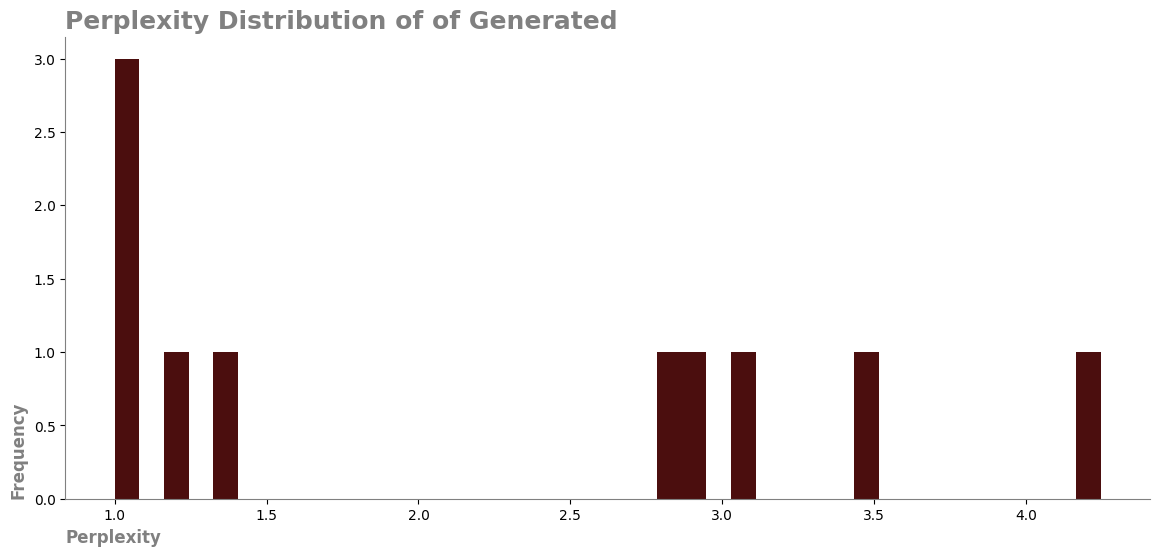

In [47]:
fig, ax = plt.subplots(figsize = (14,6))
ax.hist(perplexities, bins=40, color= "#4B0E0E");
ax.set_title("Perplexity Distribution of of Generated",
             weight = "bold",
             fontsize = 18,
             loc="left",
             color ="gray")

ax.set_xlabel("Perplexity",
                loc="left",
                weight ="bold",
                fontsize = 12,
                color = "gray")

ax.set_ylabel("Frequency",
              loc="bottom",
              weight = "bold",
              fontsize = 12,
              color="gray")


ax.spines[["right", "top"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("gray")